# Complex Numbers — From First Principles 🔄


The entire story of complex numbers can be told from a single rule:

$$i^2 = -1$$

Everything else — rotation, trig identities, angle addition — is a **consequence**.  
We don't define rotation. Rotation *emerges*.

---

### Road Map

| Step | What we do |
|:---:|---|
| 1 | A complex number is a **point / vector** in 2D |
| 2 | What should multiplication **do**? |
| 3 | Find the simplest rotation: multiplying by $i$ |
| 4 | Powers of $i$ give all 90° steps |
| 5 | Move to polar form: $\cos\theta + i\sin\theta$ |
| 6 | Multiply two rotations → angle addition |
| 7 | **Your key question**: why does *adding* vectors create a *new angle*? |
| 8 | Numerical verification |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

## Step 1 — A Complex Number Is Just a 2D Point

$$a + bi \;\;\longleftrightarrow\;\; (a,\, b)$$

Think of it as a **number** (not just a geometric point) that lives in a plane.  
Like how $9$ is a number on the number line, $3 + 4i$ is a number on the complex plane.

### Cartesian ↔ Polar

You can describe the same point two ways:

| Form | Description | Formula |
|---|---|---|
| **Cartesian** | real part + imaginary part | $a + bi$ |
| **Polar** | distance + angle | $r(\cos\theta + i\sin\theta)$ |

Converting between them is just Pythagoras and arctan:

$$r = \sqrt{a^2 + b^2}, \qquad \theta = \arctan\!\left(\frac{b}{a}\right)$$
$$a = r\cos\theta, \qquad b = r\sin\theta$$

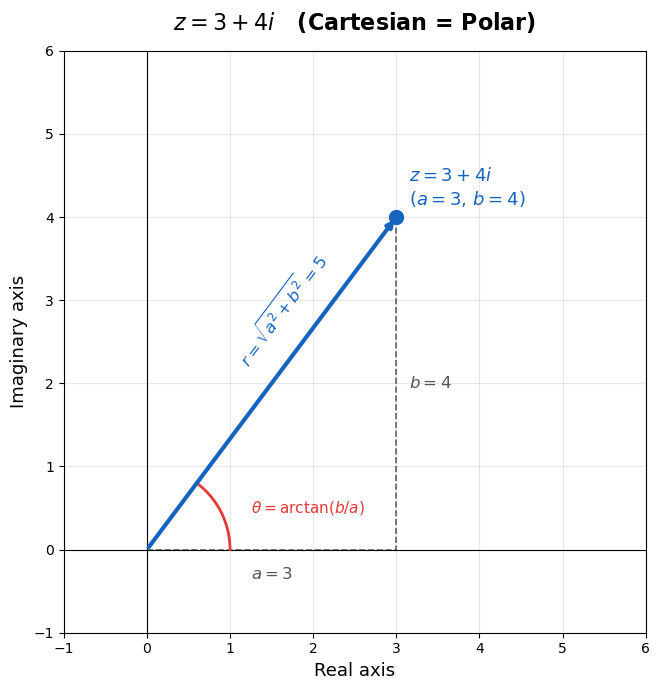

z = 3 + 4i
  r = √(3² + 4²) = 5.0000
  θ = arctan(4/3) = 53.13°


In [2]:
# === DIAGRAM 1: A complex number on the plane ===

a, b = 3, 4
r = np.sqrt(a**2 + b**2)
theta = np.arctan2(b, a)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-1, 6); ax.set_ylim(-1, 6)
ax.set_aspect('equal'); ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Real axis', fontsize=13); ax.set_ylabel('Imaginary axis', fontsize=13)
ax.set_title(f'$z = {a} + {b}i$   (Cartesian = Polar)', fontsize=16, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)

# Vector arrow
ax.annotate('', xy=(a, b), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#1565C0', lw=3))
ax.plot(a, b, 'o', color='#1565C0', ms=10, zorder=5)
ax.text(a + 0.15, b + 0.15, f'$z = {a} + {b}i$\n$(a={a},\\, b={b})$',
        fontsize=13, color='#1565C0', fontweight='bold')

# Dashed right-triangle legs
ax.plot([0, a, a], [0, 0, b], 'k--', lw=1.2, alpha=0.6)
ax.text(a / 2, -0.35, f'$a = {a}$', fontsize=12, ha='center', color='#555')
ax.text(a + 0.15, b / 2, f'$b = {b}$', fontsize=12, ha='left', va='center', color='#555')

# Arc for angle theta
arc_r = 1.0
arc_theta = np.linspace(0, theta, 100)
ax.plot(arc_r * np.cos(arc_theta), arc_r * np.sin(arc_theta), color='#E53935', lw=2)
ax.text(1.25, 0.45, r'$\theta = \arctan(b/a)$', fontsize=11, color='#E53935')

# Radius label
mid = (a / 2, b / 2)
ax.text(mid[0] - 0.5, mid[1] + 0.2, f'$r = \\sqrt{{a^2+b^2}} = {r:.0f}$',
        fontsize=12, color='#1565C0', rotation=np.degrees(theta))

plt.tight_layout()
plt.show()
print(f"z = {a} + {b}i")
print(f"  r = √({a}² + {b}²) = {r:.4f}")
print(f"  θ = arctan({b}/{a}) = {np.degrees(theta):.2f}°")

## Step 2 — What Should Multiplication Do?

We want multiplication to:

1. **Scale** → change the length (Euclidean distance)
2. **Rotate** → change the angle
3. **Obey algebra rules** → distributive, associative, etc.

We're not *defining* rotation. We're asking:  
> *"Can plain old algebra, with $i^2 = -1$, accidentally produce rotation?"*

**Spoiler: yes.**

## Step 3 — The Simplest Rotation: Multiply by $i$

**Question:** What point do you get when you rotate $(x, y)$ by 90° counterclockwise?

$$(x, y) \;\xrightarrow{\text{rotate 90°}}\; (-y,\, x)$$

**Now try it with algebra.** Multiply $(x + iy)$ by $i$, using only $i^2 = -1$:

$$
(x + iy) \cdot i
= xi + iyi
= xi + yi^2
= xi - y
= -y + xi
$$

Result: $(-y,\, x)$ — **exactly a 90° rotation**. 💥

> We never said 
. We only said $i^2 = -1$.  
> Rotation **fell out** of the algebra.

Font 'default' does not have a glyph for '\U0001f504' [U+1f504], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f504' [U+1f504], substituting with a dummy symbol.


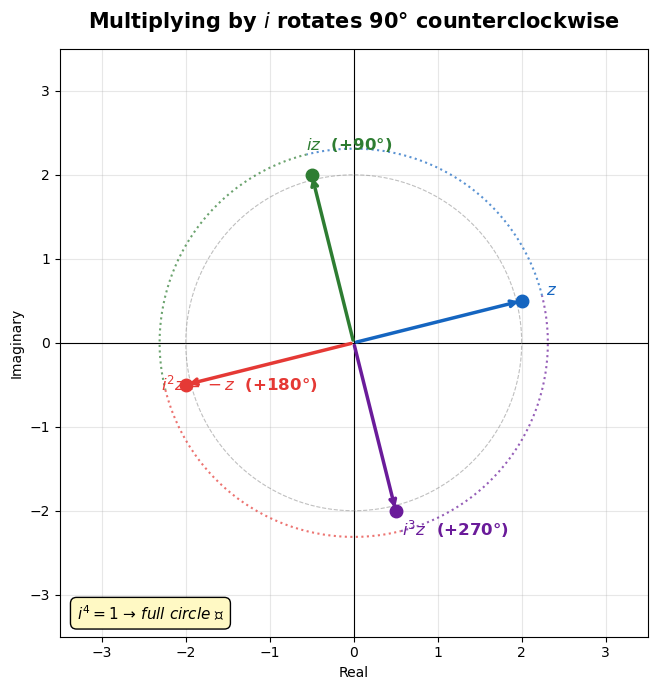

In [3]:
# === DIAGRAM 2: Multiplying by i rotates 90° ===

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.grid(True, alpha=0.3)
ax.set_title('Multiplying by $i$ rotates 90° counterclockwise', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')

# Unit circle for reference
t = np.linspace(0, 2*np.pi, 300)
ax.plot(2*np.cos(t), 2*np.sin(t), 'grey', lw=0.8, ls='--', alpha=0.5)

# Starting point z and its rotations by i
z = np.array([2.0, 0.5])   # x + iy = (2, 0.5)
colors_seq = ['#1565C0', '#2E7D32', '#E53935', '#6A1B9A']
labels = ['$z$', '$iz$  (+90°)', '$i^2z = -z$  (+180°)', '$i^3z$  (+270°)']
points = [z, np.array([-z[1], z[0]]), -z, np.array([z[1], -z[0]])]

for pt, col, lbl in zip(points, colors_seq, labels):
    ax.annotate('', xy=pt, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2.5))
    ax.plot(*pt, 'o', color=col, ms=9, zorder=5)
    offset = pt / np.linalg.norm(pt) * 0.3
    ax.text(pt[0] + offset[0], pt[1] + offset[1], lbl, fontsize=12,
            color=col, fontweight='bold')

# Curved arrows to show the rotation steps
for i in range(4):
    th1 = np.arctan2(points[i][1], points[i][0])
    th2 = np.arctan2(points[(i+1)%4][1], points[(i+1)%4][0])
    if th2 < th1: th2 += 2*np.pi
    arc = np.linspace(th1, th2, 40)
    arc_r = np.linalg.norm(points[i]) + 0.25
    ax.plot(arc_r * np.cos(arc), arc_r * np.sin(arc),
            color=colors_seq[i], lw=1.5, ls=':', alpha=0.7)

ax.text(-3.3, -3.3, '$i^4 = 1$ → full circle 🔄', fontsize=11, style='italic',
        bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

plt.tight_layout()
plt.show()

## Step 4 — Powers of $i$ Give All 90° Steps

| Power | Value | Rotation | Direction |
|:---:|:---:|:---:|---|
| $i^1$ | $i$ | 90° | up |
| $i^2$ | $-1$ | 180° | left |
| $i^3$ | $-i$ | 270° | down |
| $i^4$ | $1$ | 360° | back to start |

Multiplication already **contains** rotation.  
We only need to generalise to *any* angle.

## Step 5 — Polar Form: $\cos\theta + i\sin\theta$

We want a number that **rotates by any angle $\theta$** and stays on the unit circle (length 1).  
On the unit circle, a point at angle $\theta$ has coordinates:

$$x = \cos\theta, \qquad y = \sin\theta$$

So the number we want is:

$$\cos\theta + i\sin\theta$$

Its length (modulus) is:

$$\sqrt{\cos^2\theta + \sin^2\theta} = 1 \quad \checkmark$$

For a general complex number with length $r$ and angle $\theta$:

$$z = r(\cos\theta + i\sin\theta)$$

This is the **bridge between Cartesian and Polar** that you already understood. ✅

## Step 6 — Multiply Two Rotations: Where Angle Addition Comes From

Take two unit complex numbers:

$$z_1 = \cos\theta_1 + i\sin\theta_1, \qquad z_2 = \cos\theta_2 + i\sin\theta_2$$

Multiply — no tricks, just FOIL:

$$
z_1 \cdot z_2
= (\cos\theta_1 + i\sin\theta_1)(\cos\theta_2 + i\sin\theta_2)
$$

$$
= \cos\theta_1\cos\theta_2 + i\sin\theta_1\cos\theta_2
+ i\cos\theta_1\sin\theta_2 + i^2\sin\theta_1\sin\theta_2
$$

Using $i^2 = -1$:

$$
= \underbrace{(\cos\theta_1\cos\theta_2 - \sin\theta_1\sin\theta_2)}_{\text{real part}}
+ i\,\underbrace{(\sin\theta_1\cos\theta_2 + \cos\theta_1\sin\theta_2)}_{\text{imaginary part}}
$$

You can **check** this lands on the unit circle (real² + imag² = 1), and its angle is $\theta_1 + \theta_2$.  
Therefore we are *forced* to declare:

$$\boxed{\cos(\theta_1 + \theta_2) = \cos\theta_1\cos\theta_2 - \sin\theta_1\sin\theta_2}$$
$$\boxed{\sin(\theta_1 + \theta_2) = \sin\theta_1\cos\theta_2 + \cos\theta_1\sin\theta_2}$$

> These trig identities are **not memorised formulas** — they are just the algebra of $i^2 = -1$.

## Step 7 — New Angle

> *"How does adding the x-part and y-part create a NEW angle?"*

Here is the breakdown you spotted:

**Part A** (scale $z_1$ by $\cos\theta_2$):
$$\vec{A} = (\cos\theta_1\cos\theta_2,\;\; \sin\theta_1\cos\theta_2)$$
👉 Same direction as $\theta_1$, just **shorter by factor $\cos\theta_2$**.

**Part B** (rotate $z_1$ by 90°, then scale by $\sin\theta_2$):
$$\vec{B} = (-\sin\theta_1\sin\theta_2,\;\; \cos\theta_1\sin\theta_2)$$
👉 Direction is $\theta_1 + 90°$, shortened by factor $\sin\theta_2$.

**Adding A + B tip-to-tail:**
- $\vec{A}$ is the "forward" component
- $\vec{B}$ is the "sideways" component (perpendicular)
- Their sum creates a **diagonal** — a *new* direction

The diagonal's angle is set by how much you went forward vs sideways:

$$\text{new angle} = \arctan\!\left(\frac{\text{total }y}{\text{total }x}\right) = \theta_1 + \theta_2$$

**One-sentence answer:**  
> A vector's angle is determined by the *ratio* of its $y$ to $x$ components.  
> Adding two perpendicular vectors changes that ratio — and therefore changes the angle.

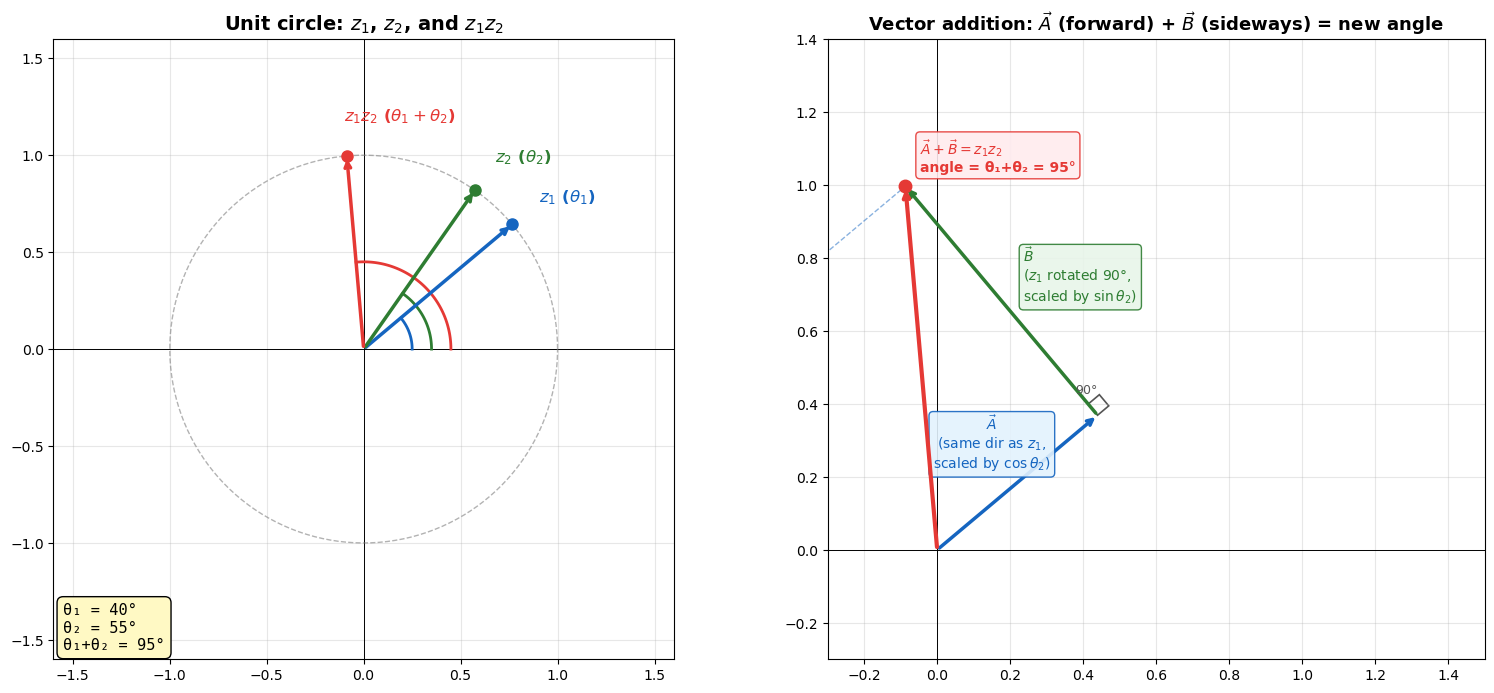

In [4]:
# === DIAGRAM 3: The KEY diagram — vector addition creates a new angle ===
# Shows Part A + Part B = z1*z2, step by step

theta1 = np.radians(40)   # angle of z1
theta2 = np.radians(55)   # angle of z2 (rotation to apply)

# The two parts
A = np.array([np.cos(theta1)*np.cos(theta2),  np.sin(theta1)*np.cos(theta2)])
B = np.array([-np.sin(theta1)*np.sin(theta2), np.cos(theta1)*np.sin(theta2)])
result = A + B   # = (cos(t1+t2), sin(t1+t2))

z1 = np.array([np.cos(theta1), np.sin(theta1)])
z2 = np.array([np.cos(theta2), np.sin(theta2)])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ─── Left panel: show z1, z2, and z1*z2 on the unit circle ───
ax = axes[0]
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
ax.grid(True, alpha=0.3)
ax.set_title('Unit circle: $z_1$, $z_2$, and $z_1 z_2$', fontsize=14, fontweight='bold')

t = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(t), np.sin(t), 'grey', lw=1, ls='--', alpha=0.6)

vectors = [(z1, '#1565C0', r'$z_1$ ($\theta_1$)'),
           (z2, '#2E7D32', r'$z_2$ ($\theta_2$)'),
           (result, '#E53935', r'$z_1 z_2$ ($\theta_1+\theta_2$)')]
for vec, col, lbl in vectors:
    ax.annotate('', xy=vec, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2.5))
    ax.plot(*vec, 'o', color=col, ms=8, zorder=5)
    off = vec / np.linalg.norm(vec) * 0.18
    ax.text(vec[0]+off[0], vec[1]+off[1], lbl, fontsize=12,
            color=col, fontweight='bold')

# Angle arcs
for th, col in [(theta1,'#1565C0'), (theta2,'#2E7D32'), (theta1+theta2,'#E53935')]:
    arc = np.linspace(0, th, 80)
    r_arc = [0.25, 0.35, 0.45][[(theta1,'#1565C0'), (theta2,'#2E7D32'), (theta1+theta2,'#E53935')].index((th,col))]
    ax.plot(r_arc*np.cos(arc), r_arc*np.sin(arc), color=col, lw=2)

ax.text(-1.55, -1.55,
        f'θ₁ = {np.degrees(theta1):.0f}°\nθ₂ = {np.degrees(theta2):.0f}°\nθ₁+θ₂ = {np.degrees(theta1+theta2):.0f}°',
        fontsize=11, family='monospace',
        bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

# ─── Right panel: the A+B vector addition diagram ───
ax2 = axes[1]
ax2.set_xlim(-0.3, 1.5); ax2.set_ylim(-0.3, 1.4)
ax2.set_aspect('equal')
ax2.axhline(0, color='k', lw=0.7); ax2.axvline(0, color='k', lw=0.7)
ax2.grid(True, alpha=0.3)
ax2.set_title('Vector addition: $\\vec{A}$ (forward) + $\\vec{B}$ (sideways) = new angle',
              fontsize=13, fontweight='bold')

origin = np.array([0, 0])

# Draw A from origin
ax2.annotate('', xy=A, xytext=origin,
             arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2.5))
ax2.text(A[0]/2 - 0.07, A[1]/2 + 0.04,
         r'$\vec{A}$' + f'\n(same dir as $z_1$,\nscaled by $\cos\\theta_2$)',
         fontsize=10, color='#1565C0', ha='center',
         bbox=dict(fc='#E3F2FD', ec='#1565C0', boxstyle='round,pad=0.3', alpha=0.9))

# Draw B from tip of A
ax2.annotate('', xy=A+B, xytext=A,
             arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2.5))
mid_B = A + B/2
ax2.text(mid_B[0] + 0.06, mid_B[1],
         r'$\vec{B}$' + f'\n($z_1$ rotated 90°,\nscaled by $\\sin\\theta_2$)',
         fontsize=10, color='#2E7D32', ha='left',
         bbox=dict(fc='#E8F5E9', ec='#2E7D32', boxstyle='round,pad=0.3', alpha=0.9))

# Draw the result (diagonal) from origin
ax2.annotate('', xy=result, xytext=origin,
             arrowprops=dict(arrowstyle='->', color='#E53935', lw=3))
ax2.text(result[0] + 0.04, result[1] + 0.04,
         r'$\vec{A}+\vec{B} = z_1 z_2$' + f'\nangle = θ₁+θ₂ = {np.degrees(theta1+theta2):.0f}°',
         fontsize=10, color='#E53935', fontweight='bold',
         bbox=dict(fc='#FFEBEE', ec='#E53935', boxstyle='round,pad=0.3', alpha=0.9))
ax2.plot(*result, 'o', color='#E53935', ms=9, zorder=6)

# Right-angle marker where A meets B
perp_size = 0.04
A_dir = A / np.linalg.norm(A)
B_dir = B / np.linalg.norm(B)
corner = A
sq_pts = [corner, corner + B_dir*perp_size, corner + A_dir*perp_size + B_dir*perp_size,
          corner + A_dir*perp_size]
ax2.add_patch(plt.Polygon(sq_pts, fill=False, edgecolor='#555', lw=1.2))
ax2.text(corner[0] - 0.06, corner[1] + 0.06, '90°', fontsize=9, color='#555')

# Dashed parallelogram completion
ax2.plot([B[0], result[0]], [B[1], result[1]], '--', color='#1565C0', lw=1, alpha=0.5)
ax2.plot([A[0], result[0]], [A[1], result[1]], '--', color='#2E7D32', lw=1, alpha=0.5)

plt.tight_layout()
plt.show()

## Step 7b — Zooming In: Why Does the Diagonal Land at $\theta_1 + \theta_2$?

You have:

$$\vec{A} = \cos\theta_2 \cdot (\cos\theta_1,\; \sin\theta_1)$$
$$\vec{B} = \sin\theta_2 \cdot (-\sin\theta_1,\; \cos\theta_1)$$

$\vec{A}$ points at angle $\theta_1$.  
$\vec{B}$ points at angle $\theta_1 + 90°$ (perpendicular to $\vec{A}$).

Think of it like this: you are standing at the origin, facing angle $\theta_1$.

- You walk **forward** a distance $\cos\theta_2$ → that's $\vec{A}$
- You then step **sideways** (left) a distance $\sin\theta_2$ → that's $\vec{B}$

How far left did you turn? Exactly $\theta_2$ — because $\cos\theta_2$ is your forward fraction and $\sin\theta_2$ is your sideways fraction — that is the **definition of rotation by $\theta_2$**.

So your final direction is $\theta_1 + \theta_2$. ✅

We can verify directly:

$$\text{angle of }(\vec{A}+\vec{B}) = \arctan\!\left(\frac{\sin\theta_1\cos\theta_2 + \cos\theta_1\sin\theta_2}{\cos\theta_1\cos\theta_2 - \sin\theta_1\sin\theta_2}\right) = \theta_1 + \theta_2$$

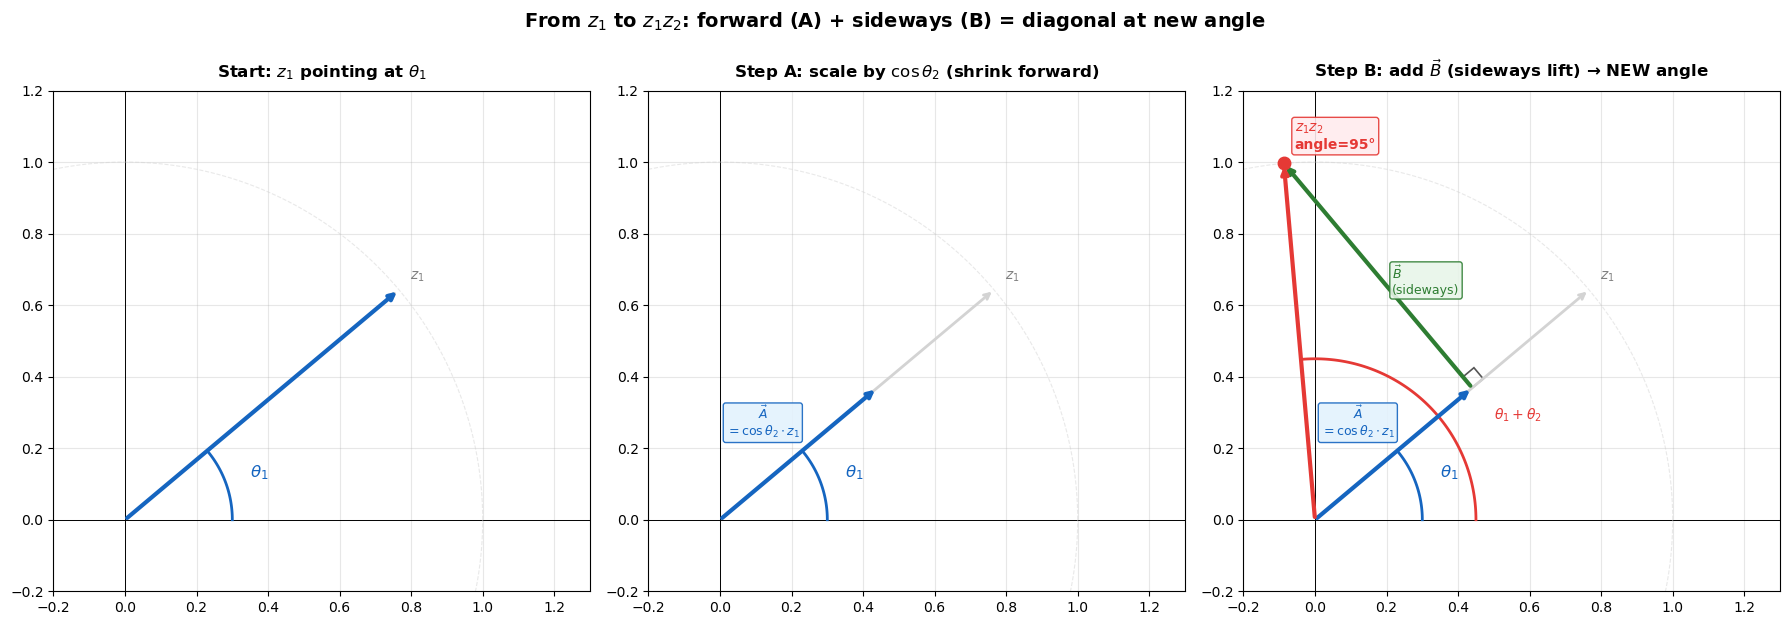

In [5]:
# === DIAGRAM 4: Step-by-step walk — forward then sideways ===
# Shows the "walking" intuition for why A+B lands at theta1+theta2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

theta1 = np.radians(40)
theta2 = np.radians(55)
A = np.array([np.cos(theta1)*np.cos(theta2), np.sin(theta1)*np.cos(theta2)])
B = np.array([-np.sin(theta1)*np.sin(theta2), np.cos(theta1)*np.sin(theta2)])
result = A + B
z1 = np.array([np.cos(theta1), np.sin(theta1)])

titles = [
    'Start: $z_1$ pointing at $\\theta_1$',
    'Step A: scale by $\\cos\\theta_2$ (shrink forward)',
    'Step B: add $\\vec{B}$ (sideways lift) → NEW angle'
]

for idx, ax in enumerate(axes):
    ax.set_xlim(-0.2, 1.3); ax.set_ylim(-0.2, 1.2)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
    ax.grid(True, alpha=0.3)
    ax.set_title(titles[idx], fontsize=12, fontweight='bold', pad=10)

    # Always draw z1 in light grey for reference
    ax.annotate('', xy=z1, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='lightgrey', lw=2))
    ax.text(z1[0]+0.03, z1[1]+0.03, '$z_1$', fontsize=10, color='grey')

    t = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(t), np.sin(t), 'lightgrey', lw=0.8, ls='--', alpha=0.5)

    if idx == 0:
        ax.annotate('', xy=z1, xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color='#1565C0', lw=3))
        arc = np.linspace(0, theta1, 80)
        ax.plot(0.3*np.cos(arc), 0.3*np.sin(arc), '#1565C0', lw=2)
        ax.text(0.35, 0.12, r'$\theta_1$', fontsize=12, color='#1565C0', fontweight='bold')

    if idx >= 1:
        ax.annotate('', xy=A, xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color='#1565C0', lw=3))
        ax.text(A[0]/2 - 0.1, A[1]/2 + 0.05,
                r'$\vec{A}$' + f'\n$= \\cos\\theta_2 \\cdot z_1$',
                fontsize=9, color='#1565C0', ha='center',
                bbox=dict(fc='#E3F2FD', ec='#1565C0', boxstyle='round,pad=0.2', alpha=0.9))
        arc = np.linspace(0, theta1, 80)
        ax.plot(0.3*np.cos(arc), 0.3*np.sin(arc), '#1565C0', lw=2)
        ax.text(0.35, 0.12, r'$\theta_1$', fontsize=12, color='#1565C0', fontweight='bold')

    if idx == 2:
        # Draw B from tip of A
        ax.annotate('', xy=A+B, xytext=A,
                    arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=3))
        mid_B = A + B/2
        ax.text(mid_B[0]+0.04, mid_B[1]-0.05,
                r'$\vec{B}$' + '\n(sideways)',
                fontsize=9, color='#2E7D32',
                bbox=dict(fc='#E8F5E9', ec='#2E7D32', boxstyle='round,pad=0.2', alpha=0.9))

        # Draw the resultant diagonal
        ax.annotate('', xy=result, xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color='#E53935', lw=3))
        ax.plot(*result, 'o', color='#E53935', ms=9, zorder=6)
        ax.text(result[0]+0.03, result[1]+0.04,
                f'$z_1 z_2$\nangle={np.degrees(theta1+theta2):.0f}°',
                fontsize=10, color='#E53935', fontweight='bold',
                bbox=dict(fc='#FFEBEE', ec='#E53935', boxstyle='round,pad=0.2', alpha=0.9))

        # New angle arc
        arc2 = np.linspace(0, theta1+theta2, 80)
        ax.plot(0.45*np.cos(arc2), 0.45*np.sin(arc2), '#E53935', lw=2)
        ax.text(0.50, 0.28, r'$\theta_1+\theta_2$', fontsize=10,
                color='#E53935', fontweight='bold')

        # Right-angle marker
        B_dir = B / np.linalg.norm(B)
        A_dir_u = A / np.linalg.norm(A)
        ps = 0.04
        sq_pts = [A, A + B_dir*ps, A + A_dir_u*ps + B_dir*ps, A + A_dir_u*ps]
        ax.add_patch(plt.Polygon(sq_pts, fill=False, edgecolor='#555', lw=1.2))

plt.suptitle('From $z_1$ to $z_1 z_2$: forward (A) + sideways (B) = diagonal at new angle',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# === DIAGRAM 5: Sweep theta2 to see the resulting angle always = theta1 + theta2 ===

theta1 = np.radians(40)
theta2_vals = np.linspace(0, np.pi, 9)   # 0° to 180° in steps

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

t = np.linspace(0, 2*np.pi, 300)

for idx, theta2 in enumerate(theta2_vals):
    ax = axes[idx]
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.grid(True, alpha=0.2)
    ax.plot(np.cos(t), np.sin(t), 'grey', lw=0.8, ls='--', alpha=0.5)

    z1  = np.array([np.cos(theta1), np.sin(theta1)])
    A   = np.cos(theta2) * z1
    z1_perp = np.array([-np.sin(theta1), np.cos(theta1)])
    B   = np.sin(theta2) * z1_perp
    res = A + B

    # z1 (faint reference)
    ax.annotate('', xy=z1, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='lightgrey', lw=1.5))

    # A
    ax.annotate('', xy=A, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2))
    # B (from tip of A)
    ax.annotate('', xy=res, xytext=A,
                arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))
    # Result
    ax.annotate('', xy=res, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='#E53935', lw=2.5))
    ax.plot(*res, 'o', color='#E53935', ms=7, zorder=6)

    actual_angle = np.degrees(np.arctan2(res[1], res[0])) % 360
    expected = (np.degrees(theta1) + np.degrees(theta2)) % 360
    ax.set_title(f'θ₂={np.degrees(theta2):.0f}° → result={actual_angle:.0f}°\n'
                 f'(θ₁+θ₂ = {np.degrees(theta1):.0f}+{np.degrees(theta2):.0f} = {expected:.0f}° ✓)',
                 fontsize=9, fontweight='bold')

plt.suptitle('Sweep: rotating $z_1$ (at 40°) by increasing $\\theta_2$\n'
             'Blue=A (forward), Green=B (sideways), Red=result',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Your Own Example — 135° × 45° ✅

You worked this out yourself and got it right:

| Quantity | Value |
|---|---|
| $z_1$ | angle $= 135°$, length $= \sqrt{2}$ |
| $z_2$ | angle $= 45°$, length $= \sqrt{2}$ |
| angles add | $135° + 45° = 180°$ |
| lengths multiply | $\sqrt{2} \times \sqrt{2} = 2$ |
| **result** | length $= 2$, angle $= 180°$ → $\mathbf{-2}$ |

$$z_1 z_2 = (-1 + i)(1 + i) = -1 - i + i + i^2 = -1 - 1 = -2 \quad \checkmark$$

In [ ]:
# === DIAGRAM 6: Your example: (-1+i)(1+i) = -2 ===

z1 = complex(-1, 1)   # angle 135°, length √2
z2 = complex(1, 1)    # angle  45°, length √2
product = z1 * z2

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-1.5, 2.5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=1); ax.axvline(0, color='k', lw=1)
ax.grid(True, alpha=0.3)
ax.set_title('Your example: $(-1+i)(1+i) = -2$', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')

for z, col, lbl in [(z1, '#1565C0', r'$z_1 = -1+i$, |z|=√2, θ=135°'),
                     (z2, '#2E7D32', r'$z_2 = 1+i$, |z|=√2, θ=45°'),
                     (product, '#E53935', r'$z_1 z_2 = -2$, |z|=2, θ=180°')]:
    ax.annotate('', xy=(z.real, z.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=col, lw=3))
    ax.plot(z.real, z.imag, 'o', color=col, ms=10, zorder=5)
    offset_x = 0.08 if z.real >= 0 else -0.08
    ax.text(z.real + offset_x, z.imag + 0.12, lbl,
            fontsize=11, color=col, fontweight='bold',
            ha='left' if z.real >= 0 else 'right',
            bbox=dict(fc='white', ec=col, boxstyle='round,pad=0.3', alpha=0.9))

# Angle arcs
for theta_deg, col in [(135, '#1565C0'), (45, '#2E7D32'), (180, '#E53935')]:
    arc = np.linspace(0, np.radians(theta_deg), 100)
    r_arc = 0.4 if theta_deg < 100 else 0.55
    ax.plot(r_arc*np.cos(arc), r_arc*np.sin(arc), color=col, lw=2)
    mid_arc = np.radians(theta_deg / 2)
    ax.text((r_arc+0.15)*np.cos(mid_arc), (r_arc+0.15)*np.sin(mid_arc),
            f'{theta_deg}°', fontsize=10, color=col, ha='center', fontweight='bold')

# Summary box
summary = "Angles: 135° + 45° = 180°\nLengths: √2 × √2 = 2\nResult: 2 at 180° = −2 ✓"
ax.text(-2.4, -1.35, summary, fontsize=12, family='monospace',
        bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

print(f"z1 = {z1}  |z1| = {abs(z1):.4f}  angle = {np.degrees(np.angle(z1)):.1f}°")
print(f"z2 = {z2}  |z2| = {abs(z2):.4f}  angle = {np.degrees(np.angle(z2)):.1f}°")
print(f"z1*z2 = {product}  |z1*z2| = {abs(product):.4f}  angle = {np.degrees(np.angle(product)):.1f}°")
print()
print(f"Length check: |z1|×|z2| = {abs(z1):.4f} × {abs(z2):.4f} = {abs(z1)*abs(z2):.4f} ✓")
print(f"Angle check:  arg(z1)+arg(z2) = {np.degrees(np.angle(z1)):.1f}° + {np.degrees(np.angle(z2)):.1f}° = {np.degrees(np.angle(z1))+np.degrees(np.angle(z2)):.1f}° ✓")

## Summary — Everything From $i^2 = -1$

| Consequence | How it follows |
|---|---|
| Multiplying by $i$ = 90° rotation | $(x+iy)\cdot i = -y + ix$ |
| Powers of $i$ = full 360° | $i^1, i^2, i^3, i^4 = i, -1, -i, 1$ |
| Polar form $r(\cos\theta + i\sin\theta)$ | Unit vector at angle $\theta$ |
| Multiplication = rotate + scale | angles add, lengths multiply |
| Trig angle-addition identities | They ARE complex multiplication |
| New angle from adding vectors | $\vec{A}$ (forward) + $\vec{B}$ (sideways) → diagonal |

### The mental model (one sentence):

> **A complex number is a rotation-and-scale machine. Multiplying two of them chains the two machines together.**

---

### The next unlock: Euler's Formula

$$e^{i\theta} = \cos\theta + i\sin\theta$$

Once you accept this, multiplication becomes:

$$e^{i\theta_1} \cdot e^{i\theta_2} = e^{i(\theta_1+\theta_2)}$$

And then angle addition is just the **exponent law** — completely obvious.

In [ ]:
https://betterexplained.com/articles/understanding-why-complex-multiplication-works/
https://betterexplained.com/articles/a-visual-intuitive-guide-to-imaginary-numbers/
